In [1]:
import networkx as nx
import random
import matplotlib.pyplot as plt

In [2]:
#zachlanne rozwiazanie
def greedy_coloring(G, population, k):
    colored = {}
    uncolored = 0
    
    for p in population:
        used_colors = set()
        
        for u in G.neighbors(p):
            if u in colored:
                used_colors.add(colored[u])
                
        for color in range(k):
            if color not in used_colors:
                colored[p] = color
                break
        else:
            uncolored += 1
                
    return colored, uncolored

In [3]:
#krzyzowanie
def crossover(p1, p2):
    n = len(p1)
    a, b = random.sample(range(n), 2)
    child = [None] * n
    child[a:b] = p1[a:b]
    fill = [x for x in p2 if x not in child]
    idx = 0
    
    for i in range(n):
        if child[i] == None:
            child[i] = fill[idx]
            idx +=1
            
    return child

In [4]:
#krzyzowanie pmx
def pmx_crossover(p1, p2):
    n = len(p1)
    a, b =sorted(random.sample(range(n), 2))
    child = [None] * n
    child[a:b] = p1[a:b]

    for i in range(a, b):
        if p2[i] not in child[a:b]:
            pos = i
            val = p2[i]
            while True:
                pos = p2.index(child[pos])
                if pos not in range(a, b):
                    break
            child[pos] = val
    for i in range(n):
        if child[i] == None:
            child[i] = p2[i]

    return child

In [5]:
#mutacja scramble
def mutation(per, p=0.25):
    if random.random() < p:
        a, b = sorted(random.sample(range(len(per)), 2))
        sset = per[a:b]
        random.shuffle(sset)
        per[a:b] = sset
        
    return per

In [6]:
#mutacja przez inwersje
def inv_mutation(per, p=0.25):
    if random.random() < p:
        a,b = sorted(random.sample(range(len(per)), 2))
        per[a:b] = reversed(per[a:b])
                            
    return per

In [7]:
#algorytm
def coloring_algorithm(G, k, tmp, cross = "ox", mut = "scramble",pop_size = 200, generations = 200):
    nodes = list(G.nodes())
    n = len(nodes)
    population = [random.sample(nodes, n) for _ in range(pop_size)]
    
    for gen in range(generations):
        score = []
        for i in population:
            _, fitness = greedy_coloring(G, i, k)
            score.append((i, fitness))
            
        score.sort(key=lambda item: item[1])
        best_fitness = score[0][1]
        
        if best_fitness == 0:
            print(parents)
            print(f"zneleziono najlepsze rozwiazanie w {gen} generacji")
            return score[0]

        new_population = [score[i][0][:] for i in range(pop_size // 10)]
        parents = [s[0][:] for s in score[:30]]

        while len(new_population) < pop_size:
            p1, p2= random.sample(parents, 2)
            match cross:
                case "ox":
                    child = crossover(p1, p2)
                case "pmx":
                    child = pmx_crossover(p1, p2)
            match mut:
                case "scramble":
                    child = mutation(child)
                case "inv":
                    child = inv_mutation(child)
            new_population.append(child)

        population = new_population
        tmp[gen] = fitness
        

    print(f"nie znaleziono najlepszego rozwiazania")
    print(parents)
    return score[0]

ox, scramble
nie znaleziono najlepszego rozwiazania
[[11, 7, 1, 6, 10, 15, 4, 8, 3, 19, 0, 17, 18, 2, 14, 16, 13, 5, 9, 12], [0, 6, 4, 13, 1, 15, 17, 11, 3, 10, 8, 19, 18, 14, 5, 7, 16, 9, 12, 2], [14, 5, 2, 9, 12, 18, 0, 3, 7, 10, 16, 13, 8, 17, 15, 1, 11, 4, 6, 19], [2, 14, 15, 18, 12, 0, 3, 6, 17, 8, 4, 19, 11, 7, 10, 9, 13, 5, 16, 1], [15, 7, 9, 16, 3, 6, 4, 14, 11, 19, 13, 5, 17, 1, 2, 8, 12, 0, 10, 18], [12, 14, 3, 2, 5, 7, 1, 6, 18, 4, 9, 13, 16, 10, 8, 17, 15, 11, 0, 19], [6, 5, 14, 12, 10, 18, 8, 3, 16, 11, 17, 7, 2, 0, 9, 19, 15, 4, 13, 1], [9, 16, 6, 3, 12, 17, 5, 7, 10, 13, 2, 0, 15, 18, 1, 8, 4, 14, 19, 11], [5, 6, 0, 16, 9, 2, 15, 7, 1, 17, 4, 12, 19, 8, 3, 18, 11, 13, 10, 14], [1, 13, 19, 6, 14, 2, 0, 3, 5, 12, 8, 4, 16, 10, 11, 18, 7, 9, 15, 17], [1, 13, 19, 6, 14, 2, 0, 3, 5, 12, 8, 4, 16, 10, 11, 18, 7, 9, 15, 17], [5, 4, 0, 15, 9, 6, 13, 11, 14, 16, 17, 7, 2, 8, 18, 10, 3, 1, 12, 19], [6, 5, 14, 12, 10, 18, 8, 3, 7, 16, 11, 17, 2, 0, 9, 19, 15, 4, 13, 1], [1, 13, 19,

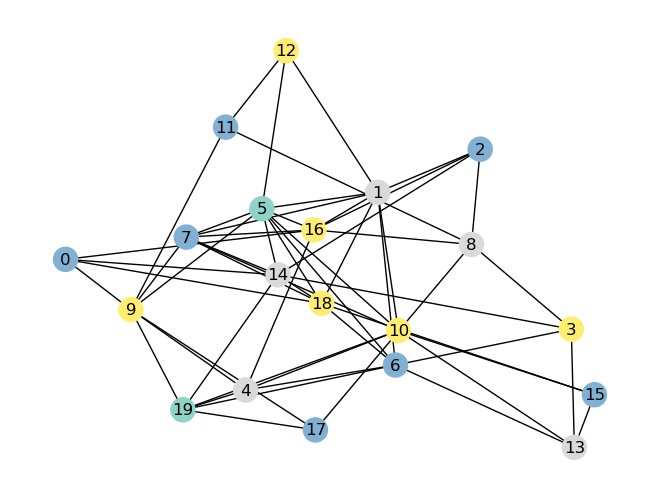

4
3
2
4
2
2
2
2
3
4
2
2
2
2
2
2
2
2
2
2
4
3
2
2
3
3
4
3
2
2
3
2
2
2
2
2
2
4
4
4
5
3
4
2
2
6
2
3
2
2
2
2
2
2
2
2
2
2
2
3
2
2
3
2
3
2
2
3
2
2
5
4
3
3
4
2
2
2
3
2
2
3
4
2
2
3
2
4
3
2
2
2
4
2
2
2
5
2
5
4
2
2
2
4
2
4
2
3
2
2
2
3
2
3
2
3
5
2
2
2
4
4
2
2
2
2
2
3
2
4
2
2
2
2
5
2
3
5
2
2
3
4
3
4
5
4
4
2
5
2
2
2
6
4
2
2
2
5
5
2
3
4
3
2
2
2
3
2
3
2
5
2
2
2
2
4
2
2
2
6
2
2
2
2
2
3
2
5
2
2
2
2
3
5
2
4
2
2
2
2
pmx, scramble
nie znaleziono najlepszego rozwiazania
[[5, 4, 7, 14, 2, 12, 15, 8, 13, 10, 9, 0, 6, 17, 19, 18, 1, 3, 11, 16], [8, 19, 4, 2, 17, 13, 7, 11, 0, 5, 9, 10, 6, 16, 15, 18, 14, 1, 12, 3], [5, 3, 0, 17, 2, 15, 11, 14, 12, 4, 19, 9, 6, 13, 18, 16, 10, 7, 8, 1], [3, 13, 0, 2, 18, 4, 15, 16, 11, 17, 10, 19, 8, 1, 7, 14, 5, 9, 12, 6], [5, 0, 15, 3, 7, 11, 4, 14, 17, 18, 8, 16, 9, 10, 13, 12, 19, 2, 1, 6], [4, 0, 12, 10, 17, 9, 2, 8, 14, 11, 15, 16, 19, 7, 6, 5, 3, 13, 18, 1], [8, 13, 2, 12, 18, 7, 16, 17, 19, 11, 3, 6, 15, 4, 10, 0, 9, 14, 1, 5], [8, 14, 6, 10, 15, 5, 18, 12, 13, 16, 17, 

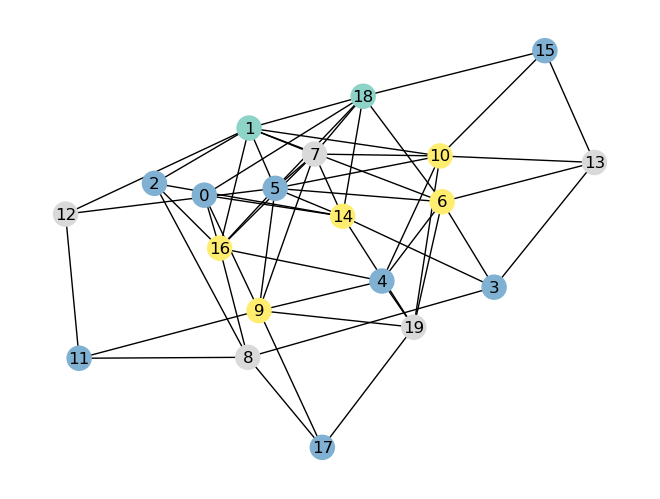

3
2
3
3
5
2
4
5
2
3
4
2
3
4
2
4
5
5
2
3
2
2
2
2
3
4
3
2
3
4
6
2
5
6
4
3
5
3
2
2
2
3
4
2
2
2
2
3
2
5
5
5
4
2
2
2
6
5
2
2
5
2
4
3
2
2
4
3
3
5
2
7
4
3
2
3
3
2
3
4
4
4
3
4
2
5
3
4
3
2
3
2
2
5
5
4
5
3
2
3
2
5
2
2
4
5
4
6
3
4
2
2
4
5
3
3
4
4
4
2
5
2
2
2
6
3
3
5
2
6
3
4
3
2
2
5
2
3
2
2
2
5
2
2
2
2
2
3
4
6
4
5
2
3
2
5
5
2
2
5
6
3
4
3
5
4
2
2
4
2
3
5
3
3
4
5
3
3
2
3
2
3
3
2
5
2
5
2
4
5
3
2
3
3
3
5
4
4
2
2
ox, inv
nie znaleziono najlepszego rozwiazania
[[10, 14, 19, 7, 12, 0, 16, 8, 4, 3, 5, 13, 18, 6, 15, 11, 9, 1, 17, 2], [5, 16, 17, 19, 11, 8, 12, 3, 0, 6, 14, 10, 2, 1, 4, 15, 7, 13, 18, 9], [5, 15, 14, 11, 12, 3, 4, 17, 0, 8, 18, 6, 7, 9, 13, 16, 10, 19, 2, 1], [15, 6, 0, 13, 10, 4, 11, 8, 7, 19, 17, 1, 18, 5, 2, 3, 14, 9, 12, 16], [0, 2, 8, 1, 11, 12, 5, 4, 15, 6, 16, 17, 7, 10, 19, 14, 13, 18, 9, 3], [14, 10, 16, 15, 13, 4, 3, 7, 9, 0, 17, 8, 11, 6, 2, 12, 5, 1, 19, 18], [8, 18, 0, 13, 16, 7, 2, 5, 14, 1, 17, 3, 19, 15, 9, 12, 6, 11, 4, 10], [5, 16, 0, 6, 15, 2, 9, 3, 18, 17, 12, 14, 1, 11

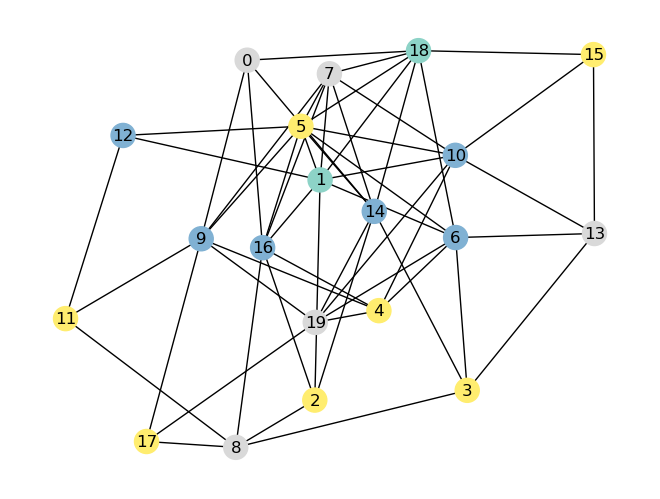

3
3
4
2
2
2
4
2
4
5
2
2
3
2
2
2
4
2
3
4
2
4
2
2
2
2
2
2
3
3
2
6
2
5
2
2
2
2
2
3
2
2
5
3
2
4
2
2
2
2
2
2
2
2
2
2
2
3
3
2
4
2
2
2
2
3
2
5
4
2
4
2
5
2
2
2
2
4
3
4
2
2
2
5
2
2
4
2
3
3
2
2
2
2
2
3
2
3
3
4
2
4
2
2
2
4
2
3
2
2
2
4
3
4
2
5
2
3
2
3
2
4
2
2
2
2
5
3
2
2
3
2
4
2
2
4
4
2
2
2
2
2
2
2
2
4
3
3
2
6
2
3
2
2
4
2
2
2
2
2
2
4
2
4
2
3
2
5
5
2
2
2
2
2
3
4
2
2
2
2
3
2
5
2
2
2
3
2
2
2
2
4
2
2
2
2
3
2
4
2
pmx, inv
nie znaleziono najlepszego rozwiazania
[[2, 14, 15, 1, 13, 6, 17, 8, 10, 16, 5, 11, 12, 18, 0, 4, 3, 9, 7, 19], [7, 15, 14, 10, 2, 3, 5, 13, 4, 1, 9, 0, 18, 11, 19, 17, 16, 8, 12, 6], [7, 15, 2, 11, 13, 16, 4, 19, 9, 14, 10, 18, 6, 5, 8, 17, 3, 12, 0, 1], [8, 19, 18, 4, 5, 13, 6, 10, 0, 9, 15, 12, 3, 16, 11, 17, 14, 2, 1, 7], [2, 4, 15, 9, 6, 14, 5, 8, 17, 18, 12, 19, 1, 0, 3, 16, 10, 11, 7, 13], [15, 3, 17, 19, 18, 2, 0, 14, 12, 10, 6, 13, 11, 7, 1, 8, 5, 16, 9, 4], [17, 4, 2, 8, 16, 15, 14, 10, 11, 5, 19, 7, 6, 9, 18, 13, 0, 3, 1, 12], [7, 15, 14, 10, 2, 3, 5, 13, 4, 1, 9, 0, 18, 11

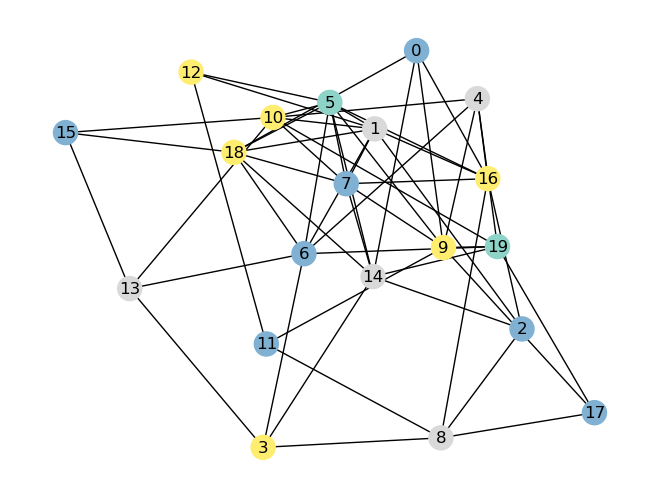

3
4
3
2
2
3
2
3
2
4
2
2
5
2
3
2
6
5
2
2
6
2
2
2
5
5
2
2
3
3
4
6
2
6
2
2
4
3
2
2
5
2
2
3
4
4
3
3
2
3
2
4
3
3
2
4
4
2
4
4
4
3
2
2
5
3
2
3
2
5
4
4
3
3
4
5
5
2
2
3
2
2
2
2
2
2
5
2
4
4
4
3
4
2
5
5
3
5
3
2
2
3
2
4
3
4
4
3
5
2
3
4
2
2
3
3
2
3
4
4
3
3
4
5
5
6
5
4
3
2
3
3
2
5
2
2
3
4
2
3
4
4
2
4
2
2
4
3
4
5
2
4
4
3
5
2
4
3
2
3
2
4
4
4
5
2
4
2
4
4
5
2
2
2
4
3
4
4
2
2
3
3
2
4
3
2
2
3
2
6
4
3
2
3
4
2
6
5
2
3


In [8]:
G = nx.gnm_random_graph(20, 55, seed=40)
k = 3
for x in range(4):
    tmp = {}
    match x:
        case 0:
            print ("ox, scramble")
            best_perm, fitness = coloring_algorithm(G, k, tmp, "ox", "scramble")
        case 1:
            print("pmx, scramble")
            best_perm, fitness = coloring_algorithm(G, k, tmp, "pmx", "scramble")
        case 2:
            print("ox, inv")
            best_perm, fitness = coloring_algorithm(G, k, tmp, "ox", "inv")
        case 3:
            print("pmx, inv")
            best_perm, fitness = coloring_algorithm(G, k, tmp, "pmx", "inv")
    coloring, _ = greedy_coloring(G, best_perm, k)
    
    print("Liczba niepokolorowanych:", fitness)
    print("Kolorowanie:", coloring)
    
    nx.draw(G, with_labels=True,
            node_color=[coloring.get(v, -1) for v in G],
            cmap=plt.cm.Set3)
    plt.show()
    for value in tmp.values():
        print(value)